In [1]:
#select short read genomes to test scaffolding approach
#author: Sheng-Kai Hsu
#created: 2024.01.22
#last edited: 2024.01.22
rm(list=ls())

In [2]:
TABASCO_score = read.csv("/workdir/hackathon_202309/data/androTABASCO_2022.12.23.csv")

In [12]:
dim(TABASCO_score)

#356:391

,speciesID,tabascoComplete,tabascoDuplicated,tabascoFraged,tabascoMissing,tabascoTotalCompleteDuplicated,tabascoTotalFragMissing
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>
356,Ab-Traiperm_572-DRAFT-PanAnd-1.0,42,5530,9,11,5572,20
357,Ac-Pasquet1232-DRAFT-PanAnd-1.0,33,5553,5,1,5586,6
358,Ag-CAM1351-DRAFT-PanAnd-1.0,4,5585,2,1,5589,3
359,Av-Kellogg1287_8-REFERENCE-PanAnd-1.0,5345,236,8,3,5581,11
360,Bl-K1279B-DRAFT-PanAnd-1.0,1,5588,2,1,5589,3
361,Cc-PI314907-DRAFT-PanAnd-1.0,12,5573,6,1,5585,7
362,Cr-AUB069-DRAFT-PanAnd-1.0,5430,146,12,4,5576,16
363,Cs-KelloggPI219580-DRAFT-PanAnd-1.0,823,4762,4,3,5585,7
364,Et-Layton_Zhong168-DRAFT-PanAnd-1.0,267,5308,8,9,5575,17


In [13]:
set.seed(123)
idx = c(sample(which(TABASCO_score[1:356,]$tabascoTotalCompleteDuplicated > 5000),2),
        sample(which(TABASCO_score[1:356,]$tabascoTotalCompleteDuplicated > 4000&
                     TABASCO_score[1:356,]$tabascoTotalCompleteDuplicated < 5000),2),
        sample(which(TABASCO_score[1:356,]$tabascoTotalCompleteDuplicated > 3000&
                     TABASCO_score[1:356,]$tabascoTotalCompleteDuplicated < 4000),2),
        sample(which(TABASCO_score[1:356,]$tabascoTotalCompleteDuplicated > 2000&
                     TABASCO_score[1:356,]$tabascoTotalCompleteDuplicated < 3000),2),
        sample(which(TABASCO_score[1:356,]$tabascoTotalCompleteDuplicated < 2000),2))



In [17]:
TABASCO_score[idx,]

,speciesID,tabascoComplete,tabascoDuplicated,tabascoFraged,tabascoMissing,tabascoTotalCompleteDuplicated,tabascoTotalFragMissing
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>
14,AN21TNTL0135,5381,110,94,7,5491,101
50,AN21TS22,5247,148,189,8,5395,197
266,AN20T175,2739,1552,1299,2,4291,1301
191,AN21TNTL0102,4021,732,837,2,4753,839
330,MCRTL034,1149,2105,2336,2,3254,2338
307,AN20T026,2349,1513,1727,3,3862,1730
344,AN21TSTL0254,1941,273,3350,28,2214,3378
339,AN21TSTL0252,1695,1303,2594,0,2998,2594
354,MCRTL024,65,1,2340,3186,66,5526


In [20]:
# load metadata
metadata=read.csv("/workdir/sh2246/p_phyloGWAS/data/androMetadata2023.08.24.csv",header = T)
# metadata$Sample=strsplit2(metadata$genome_path,split = "_|.final|.fa")[,1]
metadata$spTaxa=paste0(metadata$speciesID,": ",metadata$speciesName)
# repTrans.id=read.table("/workdir/sh2246/p_geneModelEvaluation/data/Zm-B73-REFERENCE-NAM-5.0_Zm00001eb.1.canonical_transcripts")[,1]

In [21]:
metadata

speciesID,lifeHistory,tracker_sample_name,ecotype,speciesName,altName,subspecies_cultivar,X,X.1,spTaxa
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<chr>
AN22TNTL107,,AN22TNTL107,,Anadelphia afzeliana,,,NA,NA,AN22TNTL107: Anadelphia afzeliana
AN22TNTL030,,AN22TNTL030,,Anadelphia polychaeta,,,NA,NA,AN22TNTL030: Anadelphia polychaeta
AN21TNTL0087,annual,AN21TNTL0087,Bidgood et al 5500,Anadelphia scyphofera,,,NA,NA,AN21TNTL0087: Anadelphia scyphofera
MCRTL031,annual,AT20TN1MCRTL031,Pasquet 1237,Anadelphia scyphofera,,,NA,NA,MCRTL031: Anadelphia scyphofera
AN21TSTL0285,annual,AN21TSTL0285,J.G. Adam 31646,Anadelphia trepidaria,,,NA,NA,AN21TSTL0285: Anadelphia trepidaria
AN22TNTL149,,AN22TNTL149,,Anadelphia trispiculata,,,NA,NA,AN22TNTL149: Anadelphia trispiculata
AN20T168,perennial,AN20TSCR000168,MSV 1622,Andropogon amethystinus,,,NA,NA,AN20T168: Andropogon amethystinus
MCRTL036,perennial,AT20TN1MCRTL036,NOP 89,Andropogon andringitrensis,,,NA,NA,MCRTL036: Andropogon andringitrensis
AN22TNTL109,,AN22TNTL109,,Andropogon angustatus,,,NA,NA,AN22TNTL109: Andropogon angustatus


In [200]:
testSamples = merge(TABASCO_score[idx,],metadata,by= "speciesID")

In [201]:
testSamples = testSamples[,c(1,11,6)]
testSamples$closestGenome = c("Sb-JGI-v3.fasta",
                              "Sn-CAM1369-DRAFT-PanAnd-1.0.fasta",
                              "Cr-AUB069-DRAFT-PanAnd-1.0.fasta",
                              "Cr-AUB069-DRAFT-PanAnd-1.0.fasta",
                              "Rt-Layton_Zhong169-DRAFT-PanAnd-1.0.fasta",
                              "Et-Layton_Zhong168-DRAFT-PanAnd-1.0.fasta",
                              "Td-FL_9056069_6-REFERENCE-PanAnd-2.0a.fasta",
                              "Td-FL_9056069_6-REFERENCE-PanAnd-2.0a.fasta",
                              "Rt-Layton_Zhong169-DRAFT-PanAnd-1.0.fasta",
                              "Sm-PI203595-DRAFT-PanAnd-1.0.fasta")

In [202]:
testSamples

speciesID,speciesName,tabascoTotalCompleteDuplicated,closestGenome
<chr>,<chr>,<int>,<chr>
AN20T005,Sorghum arundinaceum,584,Sb-JGI-v3.fasta
AN20T026,Sorghastrum nudipes,3862,Sn-CAM1369-DRAFT-PanAnd-1.0.fasta
AN20T175,Cymbopogon caesius,4291,Cr-AUB069-DRAFT-PanAnd-1.0.fasta
AN21TNTL0102,Cymbopogon bhutanicus,4753,Cr-AUB069-DRAFT-PanAnd-1.0.fasta
AN21TNTL0135,Thaumastochloa striata,5491,Rt-Layton_Zhong169-DRAFT-PanAnd-1.0.fasta
AN21TS22,Elionurus barbiculmis,5395,Et-Layton_Zhong168-DRAFT-PanAnd-1.0.fasta
AN21TSTL0252,Tripsacum andersonii,2998,Td-FL_9056069_6-REFERENCE-PanAnd-2.0a.fasta
AN21TSTL0254,Tripsacum lanceolatum,2214,Td-FL_9056069_6-REFERENCE-PanAnd-2.0a.fasta
MCRTL024,Ophiuros megaphyllus,66,Rt-Layton_Zhong169-DRAFT-PanAnd-1.0.fasta


In [204]:
write.table(testSamples[,c(1,4)],"/workdir/sh2246/p_phyloGWAS/data/testSamples.txt",row.names = F,col.names = F,quote = F,sep = "\t")

In [44]:
library(rtracklayer)
library(Biostrings)
library(limma)


Attaching package: ‘limma’


The following object is masked from ‘package:BiocGenerics’:

    plotMA




In [31]:
gff_old = readGFF("/workdir/sh2246/p_phyloGWAS/output/scaffoldingTest/miniProt/AN20T005.gff")
gff_new = readGFF("/workdir/sh2246/p_phyloGWAS/output/scaffoldingTest/miniProt/AN20T005.scaffolded.gff")

In [41]:
queryFa = readAAStringSet("/workdir/sh2246/p_phyloGWAS/output/Pv-672_v3.0_peptide.fa")

In [42]:
queryFa_length=width(queryFa)
names(queryFa_length)=names(queryFa)


In [46]:
gff.mrna_old = gff_old[gff_old[,3]=="mRNA",]

queryStat_old = strsplit2(gff.mrna_old$Target," ")
queryStat_old = as.data.frame(queryStat_old)
colnames(queryStat_old) = c("query","start","end")
queryStat_old$range = as.numeric(queryStat_old[,3])-as.numeric(queryStat_old[,2])+1

# query coverage
qcov_old=c()
for (i in unique(queryStat_old[,1])){
  qcov_old=c(qcov_old,queryStat_old[queryStat_old[,1]==i,4]/queryFa_length[i])
}
queryStat_old$coverage = qcov_old


In [47]:
gff.mrna_new = gff_new[gff_new[,3]=="mRNA",]

queryStat_new = strsplit2(gff.mrna_new$Target," ")
queryStat_new = as.data.frame(queryStat_new)
colnames(queryStat_new) = c("query","start","end")
queryStat_new$range = as.numeric(queryStat_new[,3])-as.numeric(queryStat_new[,2])+1

# query coverage
qcov_new=c()
for (i in unique(queryStat_new[,1])){
  qcov_new=c(qcov_new,queryStat_new[queryStat_new[,1]==i,4]/queryFa_length[i])
}
queryStat_new$coverage = qcov_new


In [48]:
head(queryStat_old)
head(queryStat_new)

,query,start,end,range,coverage
,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,Pavag01G000100.1,1,82,82,0.3727273
2,Pavag01G000200.1,214,327,114,0.2550336
3,Pavag01G000200.2,214,327,114,0.2740385
4,Pavag01G000500.3,124,501,378,0.2988142
5,Pavag01G000500.1,323,700,378,0.2573179
6,Pavag01G000500.2,323,700,378,0.2581967


,query,start,end,range,coverage
,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,Pavag01G000100.1,1,82,82,0.3727273
2,Pavag01G000200.1,134,442,309,0.6912752
3,Pavag01G000200.2,134,413,280,0.6730769
4,Pavag01G000500.3,1,1265,1265,1.0000000
5,Pavag01G000500.1,33,1469,1437,0.9782165
6,Pavag01G000500.2,33,1464,1432,0.9781421


In [54]:
queryStat_old_primary = queryStat_old[gff.mrna_old$Rank == 1,]
queryStat_new_primary = queryStat_new[gff.mrna_new$Rank == 1,]

In [56]:
rownames(queryStat_old_primary) = queryStat_old_primary[,1]
rownames(queryStat_new_primary) = queryStat_new_primary[,1]

In [59]:
dim(queryStat_old_primary)
dim(queryStat_new_primary)

[1] 36466     5

[1] 36997     5

In [82]:
library(scales)

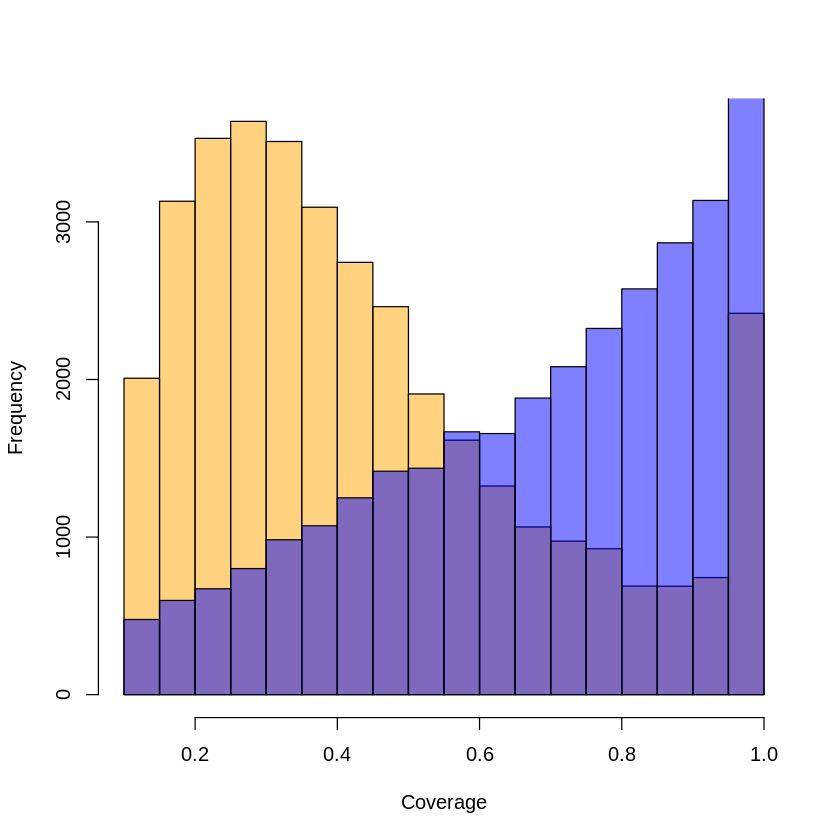

In [171]:
options(repr.plot.width=7, repr.plot.height=7)
hist(queryStat_old_primary$coverage,xlab = "Coverage",main = "", col = alpha("orange",.5))
hist(queryStat_new_primary$coverage,add = T, col = alpha("blue",.5))


In [60]:
common_anchor = intersect(rownames(queryStat_old_primary),rownames(queryStat_new_primary))

In [85]:
library(LSD)

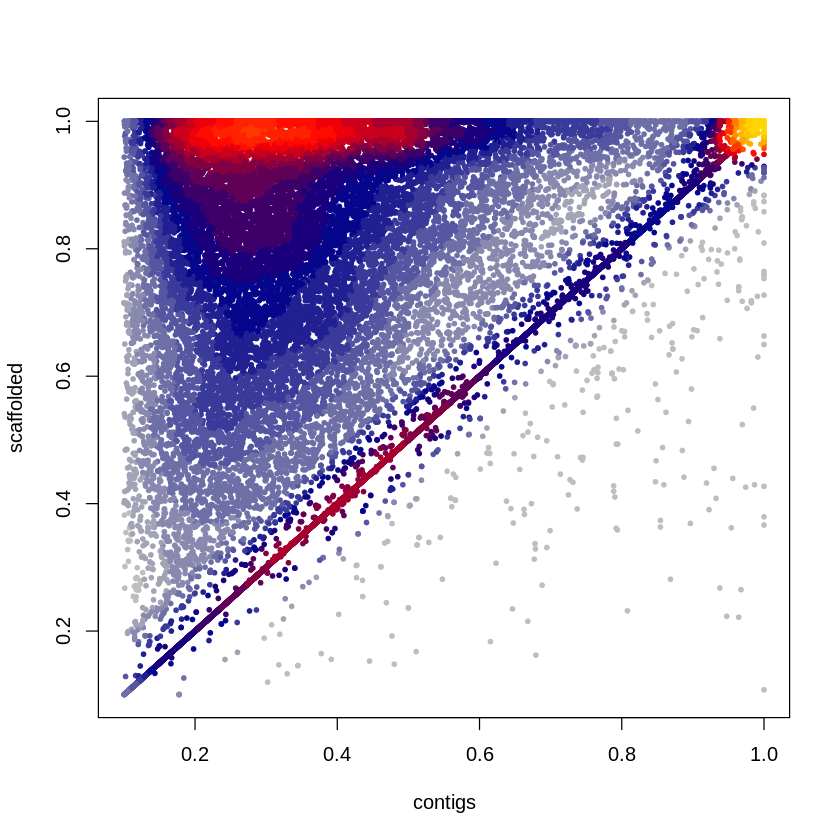

In [88]:
heatscatter(queryStat_old_primary[common_anchor,]$coverage,queryStat_new_primary[common_anchor,]$coverage,
     xlab = "contigs", ylab = "scaffolded", main = "")

In [70]:
which(queryStat_new_primary[common_anchor,]$coverage-queryStat_old_primary[common_anchor,]$coverage< -0.5)

[1]  1718  1874  1929  3161  5231  7477  7813  9155 20652 20657 20796 21227
[13] 25530 29009 31799 31960 35084 35974

In [94]:
queryStat_new_primary[common_anchor,][which(queryStat_new_primary[common_anchor,]$coverage-queryStat_old_primary[common_anchor,]$coverage< -0.5),]
queryStat_old_primary[common_anchor,][which(queryStat_new_primary[common_anchor,]$coverage-queryStat_old_primary[common_anchor,]$coverage< -0.5),]

,query,start,end,range,coverage
,<chr>,<chr>,<chr>,<dbl>,<dbl>
Pavag01G163200.1,Pavag01G163200.1,301,526,226,0.4296578
Pavag01G179200.1,Pavag01G179200.1,1,35,35,0.2317881
Pavag01G184000.1,Pavag01G184000.1,1,109,109,0.4082397
Pavag01G301900.1,Pavag01G301900.1,179,310,132,0.4258065
Pavag01G489200.1,Pavag01G489200.1,432,560,129,0.1622642
Pavag02G185100.1,Pavag02G185100.1,136,299,164,0.2649435
Pavag02G216900.1,Pavag02G216900.1,60,103,44,0.4271845
Pavag02G335800.1,Pavag02G335800.1,1,11,11,0.1078431
Pavag05G270000.1,Pavag05G270000.1,724,929,206,0.2217438


,query,start,end,range,coverage
,<chr>,<chr>,<chr>,<dbl>,<dbl>
Pavag01G163200.1,Pavag01G163200.1,8,526,519,0.9866920
Pavag01G179200.1,Pavag01G179200.1,22,143,122,0.8079470
Pavag01G184000.1,Pavag01G184000.1,8,256,249,0.9325843
Pavag01G301900.1,Pavag01G301900.1,1,302,302,0.9741935
Pavag01G489200.1,Pavag01G489200.1,132,671,540,0.6792453
Pavag02G185100.1,Pavag02G185100.1,21,619,599,0.9676898
Pavag02G216900.1,Pavag02G216900.1,1,103,103,1.0000000
Pavag02G335800.1,Pavag02G335800.1,1,102,102,1.0000000
Pavag05G270000.1,Pavag05G270000.1,1,896,896,0.9644779


In [102]:
badID = queryStat_new_primary[common_anchor,][which(queryStat_new_primary[common_anchor,]$coverage-queryStat_old_primary[common_anchor,]$coverage< -0.5),1]
length(badID)
gff.mrna_old[strsplit2(gff.mrna_old$Target," ")[,1]%in%badID,]
gff.mrna_new[strsplit2(gff.mrna_new$Target," ")[,1]%in%badID&gff.mrna_new$Rank ==1,]


[1] 18

DataFrame with 18 rows and 18 columns
          seqid   source     type     start       end     score      strand
       <factor> <factor> <factor> <integer> <integer> <numeric> <character>
1   k141_182507 miniprot     mRNA       155      1609       798           -
2   k141_471503 miniprot     mRNA         1       363        58           -
3   k141_328505 miniprot     mRNA       206      1012       462           -
4   k141_72599  miniprot     mRNA       389      1852       692           +
5   k141_723445 miniprot     mRNA        14      1714       740           -
...         ...      ...      ...       ...       ...       ...         ...
14  k141_276017 miniprot     mRNA      1566      2189       473           +
15  k141_449893 miniprot     mRNA       166       850       279           -
16  k141_416619 miniprot     mRNA        97      1356       548           -
17  k141_337988 miniprot     mRNA        45       994       372           -
18  k141_116157 miniprot     mRNA        10       

DataFrame with 18 rows and 18 columns
           seqid   source     type     start       end     score      strand
        <factor> <factor> <factor> <integer> <integer> <numeric> <character>
1   Chr01_RagTag miniprot     mRNA   5890273   5891756       833           +
2   Chr03_RagTag miniprot     mRNA   4624130   4624234        55           +
3   Chr01_RagTag miniprot     mRNA   6844293   6845779       455           +
4   Chr01_RagTag miniprot     mRNA  12918366  12918761       567           -
5   Chr01_RagTag miniprot     mRNA  19596986  19597372       607           +
...          ...      ...      ...       ...       ...       ...         ...
14  Chr09_RagTag miniprot     mRNA   5052656   5054288       471           +
15  Chr10_RagTag miniprot     mRNA   3488924   3489022       164           -
16  Chr10_RagTag miniprot     mRNA   4528918   4529217       413           -
17  Chr05_RagTag miniprot     mRNA  15228987  15229262       329           -
18  Chr03_RagTag miniprot     mRNA   4

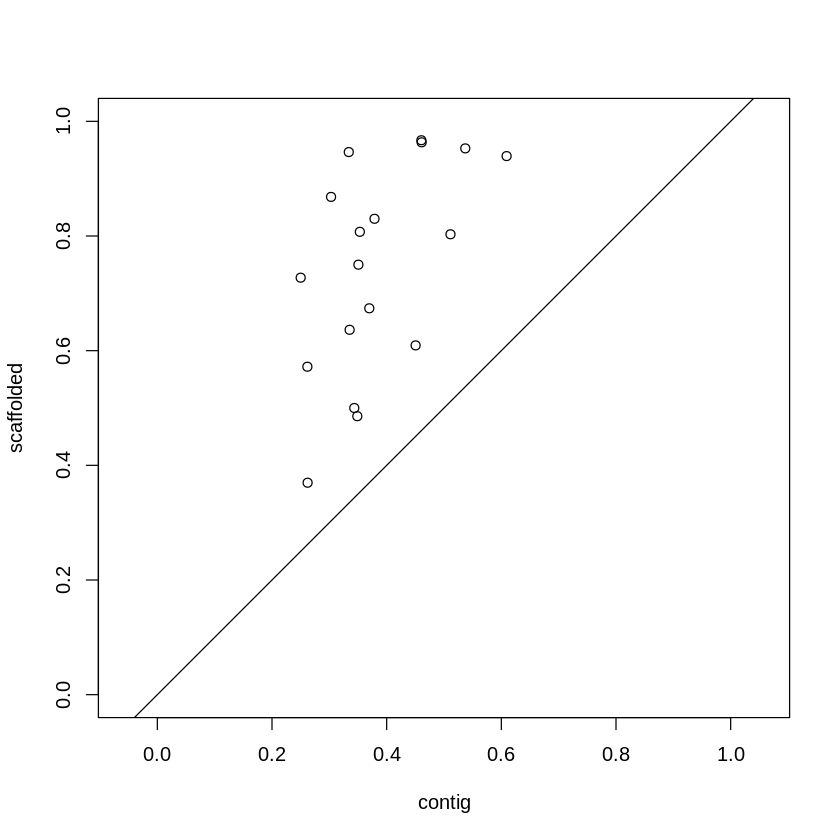

In [106]:
# hist(as.numeric(gff.mrna_old[strsplit2(gff.mrna_old$Target," ")[,1]%in%badID,11]))
# hist(as.numeric(gff.mrna_new[strsplit2(gff.mrna_new$Target," ")[,1]%in%badID&gff.mrna_new$Rank ==1,11]))

plot(as.numeric(gff.mrna_old[strsplit2(gff.mrna_old$Target," ")[,1]%in%badID,11]),
     as.numeric(gff.mrna_new[strsplit2(gff.mrna_new$Target," ")[,1]%in%badID&gff.mrna_new$Rank ==1,11]),
     asp =1,xlim = c(0,1),ylim = c(0,1),xlab = "contig",ylab = "scaffolded")
abline(a =0, b = 1)

In [125]:
head(intersect(queryStat_old[duplicated(queryStat_old[,1]),1],
               common_anchor[which(queryStat_new_primary[common_anchor,]$coverage>0.95&
                         queryStat_old_primary[common_anchor,]$coverage< 0.5)]))

[1] "Pavag01G022300.1" "Pavag01G022500.2" "Pavag01G026100.1" "Pavag01G030100.1"
[5] "Pavag01G058800.1" "Pavag01G068200.1"

In [129]:
gff_old[grep("Pavag01G022300.1",gff_old$Target),]
gff_new[grep("Pavag01G022300.1",gff_new$Target),]

DataFrame with 5 rows and 18 columns
        seqid   source     type     start       end     score      strand
     <factor> <factor> <factor> <integer> <integer> <numeric> <character>
1 k141_183403 miniprot     mRNA       130       357       219           +
2 k141_183403 miniprot     CDS        130       198       110           +
3 k141_183403 miniprot     CDS        277       354       109           +
4 k141_50253  miniprot     mRNA       560       730       223           -
5 k141_50253  miniprot     CDS        560       730       223           -
      phase          ID        Rank    Identity    Positive
  <integer> <character> <character> <character> <character>
1        NA    MP000245           1      0.9388      0.9388
2         0          NA           1      1.0000          NA
3         0          NA           1      0.8846          NA
4        NA    MP000246           2      0.8596      0.8596
5         0          NA           2      0.8596          NA
                  Target 

DataFrame with 5 rows and 18 columns
         seqid   source     type     start       end     score      strand
      <factor> <factor> <factor> <integer> <integer> <numeric> <character>
1 Chr01_RagTag miniprot     mRNA    796349    799316       505           -
2 Chr01_RagTag miniprot     CDS     799146    799316       223           -
3 Chr01_RagTag miniprot     CDS     797121    797176        68           -
4 Chr01_RagTag miniprot     CDS     796508    796574       105           -
5 Chr01_RagTag miniprot     CDS     796352    796429       109           -
      phase          ID        Rank    Identity    Positive
  <integer> <character> <character> <character> <character>
1        NA    MP000240           1      0.8871      0.8871
2         0          NA           1      0.8596          NA
3         0          NA           1      0.8421          NA
4         1          NA           1      1.0000          NA
5         0          NA           1      0.8846          NA
                  

In [89]:
agp = read.table("/workdir/sh2246/p_phyloGWAS/output/scaffoldingTest/AN20T005/ragtag.scaffold.agp",skip = 2)

In [127]:
agp[agp$V6%in%c("k141_183403","k141_50253"),]

,V1,V2,V3,V4,V5,V6,V7,V8,V9
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
2199,Chr01_RagTag,795412,796705,2199,W,k141_183403,1,1294,-
2205,Chr01_RagTag,798587,799432,2205,W,k141_50253,1,846,+


In [128]:
agp[2199:2205,]

,V1,V2,V3,V4,V5,V6,V7,V8,V9
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
2199,Chr01_RagTag,795412,796705,2199,W,k141_183403,1,1294,-
2200,Chr01_RagTag,796706,796805,2200,U,100,scaffold,yes,align_genus
2201,Chr01_RagTag,796806,797453,2201,W,k141_59168,1,648,+
2202,Chr01_RagTag,797454,797553,2202,U,100,scaffold,yes,align_genus
2203,Chr01_RagTag,797554,798486,2203,W,k141_393521,1,933,-
2204,Chr01_RagTag,798487,798586,2204,U,100,scaffold,yes,align_genus
2205,Chr01_RagTag,798587,799432,2205,W,k141_50253,1,846,+


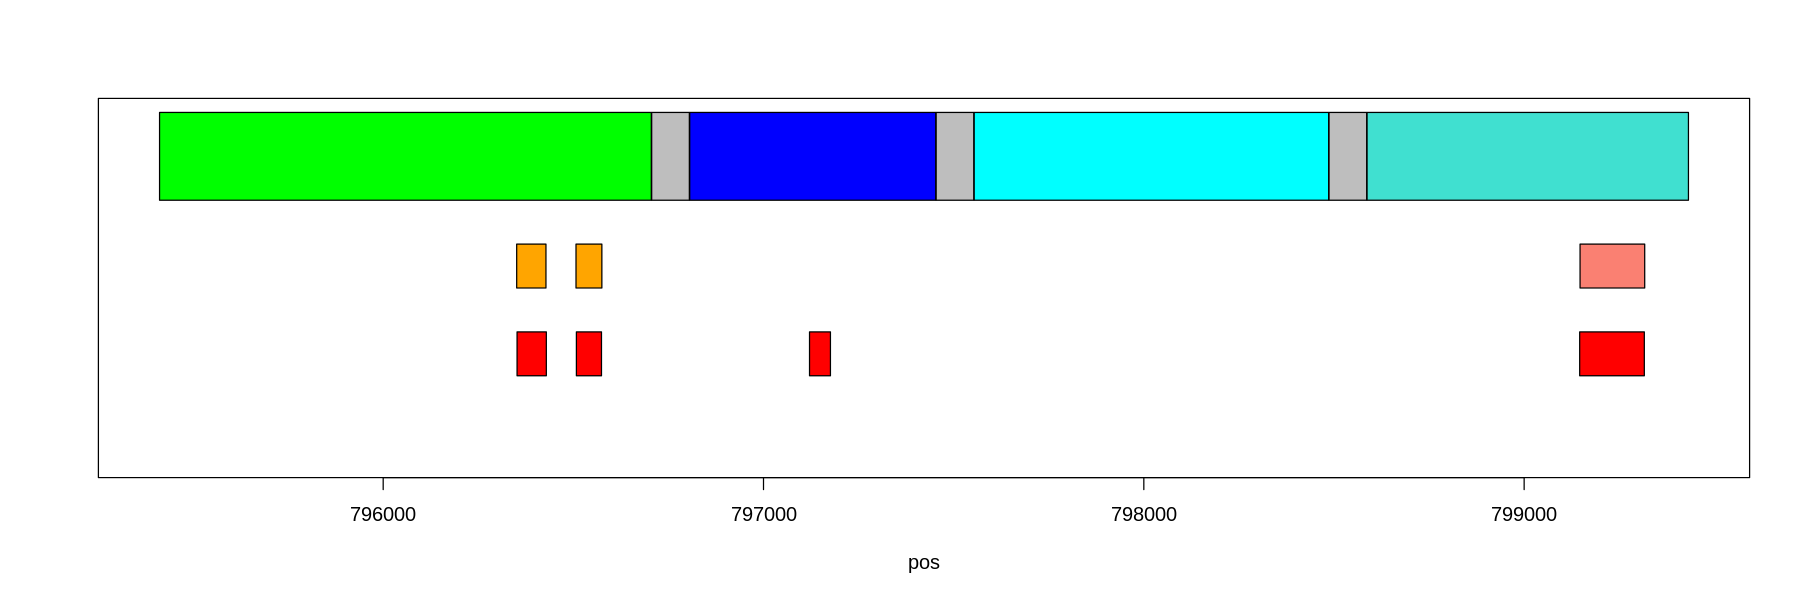

In [166]:
options(repr.plot.width=15, repr.plot.height=5)
plot(unlist(agp[2199:2205,2:3]),rep(1,14),ylim = c(0.6,1),type ='n',xlab = "pos",ylab = "",yaxt ='n')
rect(xleft = agp[2199:2205,2],xright = agp[2199:2205,3],ybottom = 0.9,ytop = 1,
     col = c("green","grey","blue","grey","cyan","grey","turquoise"))
rect(xleft = gff_new[grepl("Pavag01G022300.1",gff_new$Target)&gff_new$type=="CDS",4],
     xright = gff_new[grepl("Pavag01G022300.1",gff_new$Target)&gff_new$type=="CDS",5],
     ybottom = 0.7,ytop = .75,
     col = "red")
rect(xleft = -gff_old[grepl("Pavag01G022300.1",gff_old$Target)&gff_old$type=="CDS",4][1:2]+796705,
     xright = -gff_old[grepl("Pavag01G022300.1",gff_old$Target)&gff_old$type=="CDS",5][1:2]+796705,
     ybottom = 0.8,ytop = .85,
     col = "orange")
rect(xleft = gff_old[grepl("Pavag01G022300.1",gff_old$Target)&gff_old$type=="CDS",4][3]+798587,
     xright = gff_old[grepl("Pavag01G022300.1",gff_old$Target)&gff_old$type=="CDS",5][3]+798587,
     ybottom = 0.8,ytop = .85,
     col = "salmon")


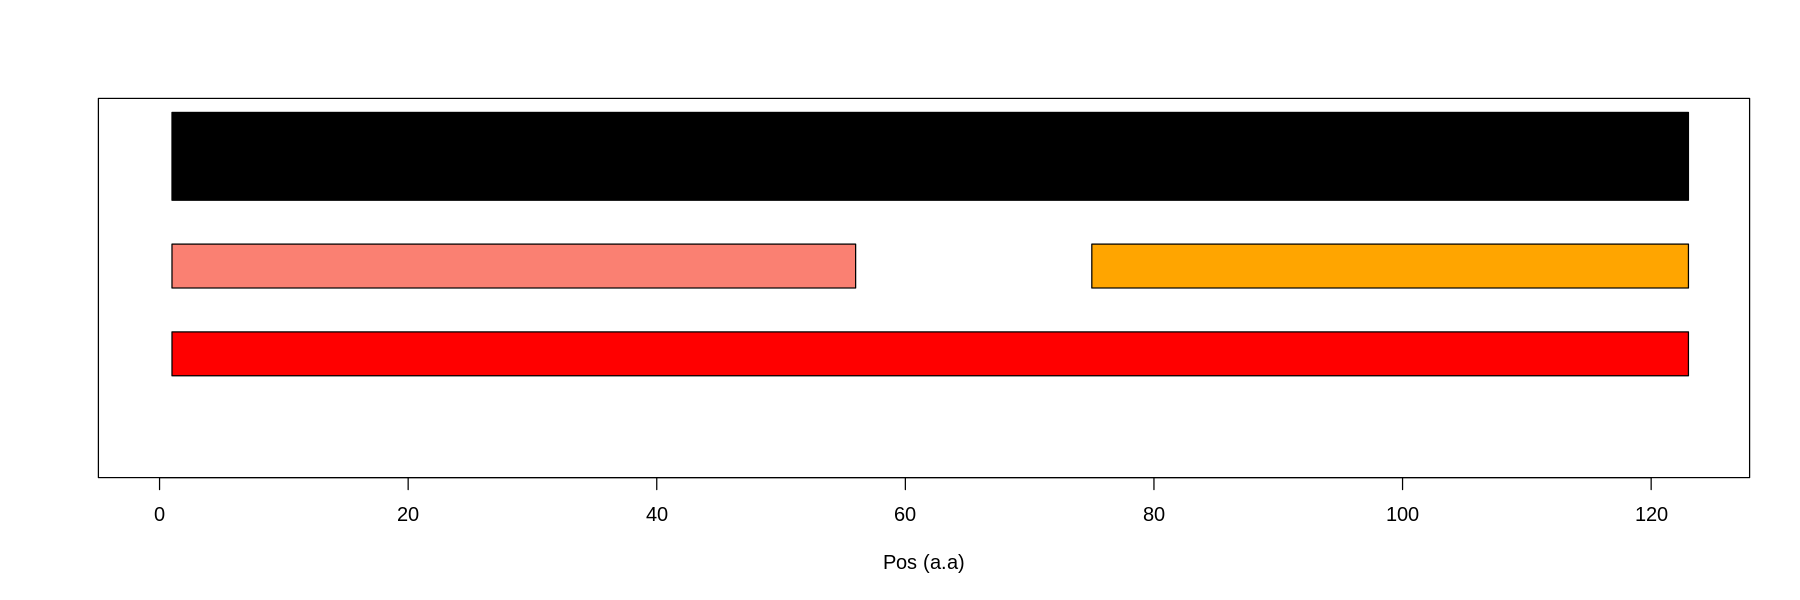

In [168]:
options(repr.plot.width=15, repr.plot.height=5)
plot(0,0,xlim= c(0,queryFa_length["Pavag01G022300.1"]),ylim= c(0.6,1),type = 'n',xlab = "Pos (a.a)",
     ylab = "", yaxt = 'n')
rect(xleft = 1,xright = queryFa_length["Pavag01G022300.1"],ybottom = 0.9,ytop = 1,col = c("black"))
rect(xleft = queryStat_new[queryStat_new[,1]=="Pavag01G022300.1",2],
     xright = queryStat_new[queryStat_new[,1]=="Pavag01G022300.1",3],
     ybottom = 0.7,ytop = .75,col = c("red"))

rect(xleft = queryStat_old[queryStat_old[,1]=="Pavag01G022300.1",2],
     xright = queryStat_old[queryStat_old[,1]=="Pavag01G022300.1",3],
     ybottom = 0.8,ytop = .85,col = c("orange","salmon"))


In [173]:
aln = read.delim("/workdir/sh2246/p_phyloGWAS/output/scaffoldingTest/AN20T005/ragtag.scaffold.asm.paf",header = F)

In [174]:
head(aln)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,k141_395744,211,7,210,-,Chr04,68658214,41506723,41506926,149,203,0,tp:A:P,cm:i:14,s1:i:149,s2:i:147,dv:f:0.0235,rl:i:0
2,k141_395744,211,7,183,+,Chr09,59416394,4164048,4164224,147,176,0,tp:A:S,cm:i:12,s1:i:147,dv:f:0.0211,rl:i:0,
3,k141_395744,211,29,210,-,Chr02,77742459,5401457,5401638,147,181,0,tp:A:S,cm:i:15,s1:i:147,dv:f:0.0176,rl:i:0,
4,k141_395744,211,7,162,+,Chr08,62686529,23821582,23821737,147,155,0,tp:A:S,cm:i:12,s1:i:147,dv:f:0.0117,rl:i:0,
5,k141_395744,211,29,210,-,Chr08,62686529,12681648,12681829,147,181,0,tp:A:S,cm:i:15,s1:i:147,dv:f:0.0176,rl:i:0,
6,k141_395744,211,7,183,+,Chr05,71854669,17785560,17785736,147,176,0,tp:A:S,cm:i:12,s1:i:147,dv:f:0.0211,rl:i:0,


In [178]:
target_aln = aln[aln[,1]%in%c("k141_183403","k141_59168","k141_393521","k141_50253"),][1:4,]
target_aln

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
220260,k141_50253,846,14,843,+,Chr01,80884392,1995087,1995923,765,836,60,tp:A:P,cm:i:71,s1:i:763,s2:i:0,dv:f:0.0007,rl:i:0
2737254,k141_59168,648,17,635,+,Chr01,80884392,1993189,1993807,549,618,60,tp:A:P,cm:i:55,s1:i:549,s2:i:0,dv:f:0.0009,rl:i:0
2880604,k141_183403,1294,10,1284,-,Chr01,80884392,1991877,1993151,1219,1274,60,tp:A:P,cm:i:109,s1:i:1219,s2:i:0,dv:f:0.0010,rl:i:0
6397458,k141_393521,933,183,802,-,Chr01,80884392,1994419,1995038,411,619,60,tp:A:P,cm:i:36,s1:i:411,s2:i:306,dv:f:0.0182,rl:i:0


In [186]:
TE = read.table("/workdir/sh2246/p_phyloGWAS/data/Sbicolor_313_v3.1.repeatmasked_assembly_v3.0.gff3",header = F)

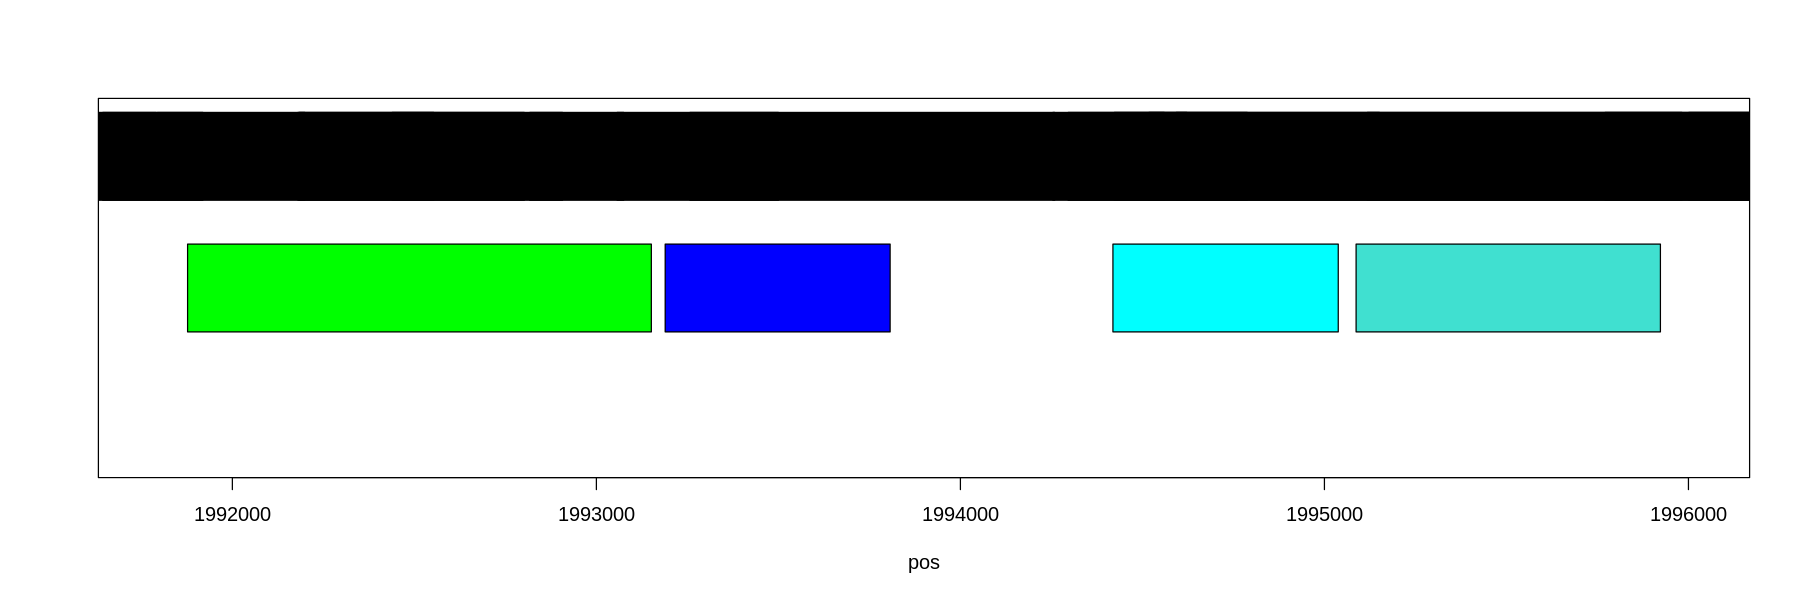

In [197]:
options(repr.plot.width=15, repr.plot.height=5)
plot(0,0,xlim = c(1991800,1996000),ylim = c(0.6,1),type ='n',xlab = "pos",ylab = "",yaxt ='n')
rect(xleft = target_aln[,8],xright = target_aln[,9],ybottom = 0.75,ytop = .85,
     col = c("green","blue","cyan","turquoise")[c(4,2,1,3)])
rect(xleft = TE[TE[,6]<10,4],xright = TE[TE[,6]<10,5],ybottom = 0.9,ytop = 1,col = "black")


In [189]:
table(TE[,3])


similarity 
    519156 

In [162]:
queryStat_old

query,start,end,range,coverage
<chr>,<chr>,<chr>,<dbl>,<dbl>
Pavag01G000100.1,1,82,82,0.3727273
Pavag01G000200.1,214,327,114,0.2550336
Pavag01G000200.2,214,327,114,0.2740385
Pavag01G000500.3,124,501,378,0.2988142
Pavag01G000500.1,323,700,378,0.2573179
Pavag01G000500.2,323,700,378,0.2581967
Pavag01G000600.1,13,87,75,0.3073770
Pavag01G000700.1,709,812,104,0.1037924
Pavag01G000700.2,701,804,104,0.1046278


In [146]:
gff_old[grepl("Pavag01G022300.1",gff_old$Target)&gff_old$type=="CDS",]

DataFrame with 3 rows and 18 columns
        seqid   source     type     start       end     score      strand
     <factor> <factor> <factor> <integer> <integer> <numeric> <character>
1 k141_183403 miniprot      CDS       130       198       110           +
2 k141_183403 miniprot      CDS       277       354       109           +
3 k141_50253  miniprot      CDS       560       730       223           -
      phase          ID        Rank    Identity    Positive
  <integer> <character> <character> <character> <character>
1         0          NA           1      1.0000          NA
2         0          NA           1      0.8846          NA
3         0          NA           2      0.8596          NA
                  Target          Parent       Donor  Frameshift    Acceptor
             <character> <CharacterList> <character> <character> <character>
1 Pavag01G022300.1 75 97        MP000245          NA          NA          NA
2 Pavag01G022300.1 98 ..        MP000245          NA          

In [50]:
dim(queryStat_old)
dim(queryStat_new)

[1] 38057     5

[1] 38129     5

In [52]:
length(unique(queryStat_old$query))
length(unique(queryStat_new$query))

[1] 36491

[1] 36997

In [33]:
head(gff_new)

DataFrame with 6 rows and 18 columns
         seqid   source     type     start       end     score      strand
      <factor> <factor> <factor> <integer> <integer> <numeric> <character>
1 Chr01_RagTag miniprot     mRNA      1426      1677       342           +
2 Chr01_RagTag miniprot     CDS       1426      1677       342           +
3 Chr01_RagTag miniprot     mRNA     14299     16601      1300           -
4 Chr01_RagTag miniprot     CDS      16430     16601       194           -
5 Chr01_RagTag miniprot     CDS      16075     16197       212           -
6 Chr01_RagTag miniprot     CDS      15800     15888       156           -
      phase          ID        Rank    Identity    Positive
  <integer> <character> <character> <character> <character>
1        NA    MP000001           1      0.8235      0.8824
2         0          NA           1      0.8235          NA
3        NA    MP000002           1      0.8386      0.8892
4         0          NA           1      0.7627          NA
5  

In [ ]:
gff_old$Target[3]
gff_new$Target[3]

In [37]:
#ploidy test

[1] "Pavag01G000200.1 214 327"

[1] "Pavag01G000200.1 134 442"

In [207]:
panandPloidy = read.delim("/workdir/sh2246/p_panAndOGASR/data/panand_assembly_sizes.txt")
panandPloidy[grep("tdac",panandPloidy[,1]),1] = c("tdacn","tdacs")

In [208]:
panandPloidy[panandPloidy[,2]==T&panandPloidy[,5]=="Diploid",1]
panandPloidy[panandPloidy[,2]==F&panandPloidy[,5]=="Diploid",1]
panandPloidy[panandPloidy[,2]==T&panandPloidy[,5]=="Tetraploid",1]
panandPloidy[panandPloidy[,2]==F&panandPloidy[,5]=="Tetraploid",1]
panandPloidy[panandPloidy[,2]==T&panandPloidy[,5]=="Hexaploid",1]
panandPloidy[panandPloidy[,2]==F&panandPloidy[,5]=="Hexaploid",1]

[1] "avirgi" "crefra" "irugos" "ppanic" "rtuber" "smicro" "sbicol"

[1] "cserru" "telega" "ttrian"

[1] "achine" "etrips" "rrottb"

[1] "atenui" "ccitra" "hconto" "sscopa" "snutan" "vcuspi"

[1] "udigit"

[1] "agerar" "blagur" "hcompr"

In [241]:
agp_ploidy = read.table("/workdir/sh2246/p_phyloGWAS/output/scaffoldingTest/ploidy/Ac-Pasquet1232-DRAFT-PanAnd-1.0/ragtag.scaffold.agp",skip = 2)

In [242]:
head(agp_ploidy)

,V1,V2,V3,V4,V5,V6,V7,V8,V9
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ctg_1_RagTag,1,710,1,W,ctg_1:15282-15992,1,710,+
2,ctg_1_RagTag,711,810,2,U,100,scaffold,yes,align_genus
3,ctg_1_RagTag,811,1520,3,W,ctg_1:16213-16923,1,710,+
4,ctg_1_RagTag,1521,1620,4,U,100,scaffold,yes,align_genus
5,ctg_1_RagTag,1621,2330,5,W,ctg_1:16794-17504,1,710,+
6,ctg_1_RagTag,2331,2430,6,U,100,scaffold,yes,align_genus


In [243]:
sum(agp_ploidy[,5]=="W"&gsub("_RagTag","",agp_ploidy[,1])==strsplit2(agp_ploidy[,6],":")[,1])

[1] 2070449

In [244]:
contigPos = strsplit2(agp_ploidy[agp_ploidy[,5]=="W",6],":")

In [245]:
contigPos = cbind(contigPos[,1],strsplit2(contigPos[,2],"-"))

In [246]:
contigPos = cbind(contigPos,grepl("RagTag",agp_ploidy[agp_ploidy[,5]=="W",1]))

In [250]:
a = contigPos[contigPos[,1]=="ctg_1",]

In [252]:
library(rtracklayer)

In [253]:
gff_Ac = readGFF("/workdir/sh2246/p_evolBNI/data/annotations_final/02_Ac-Pasquet1232-DRAFT-PanAnd-1.0_final.gff3")

In [256]:
gff_Ac_ctg1 = gff_Ac[gff_Ac[,1]=="ctg_1"&gff_Ac[,3]=="gene",]

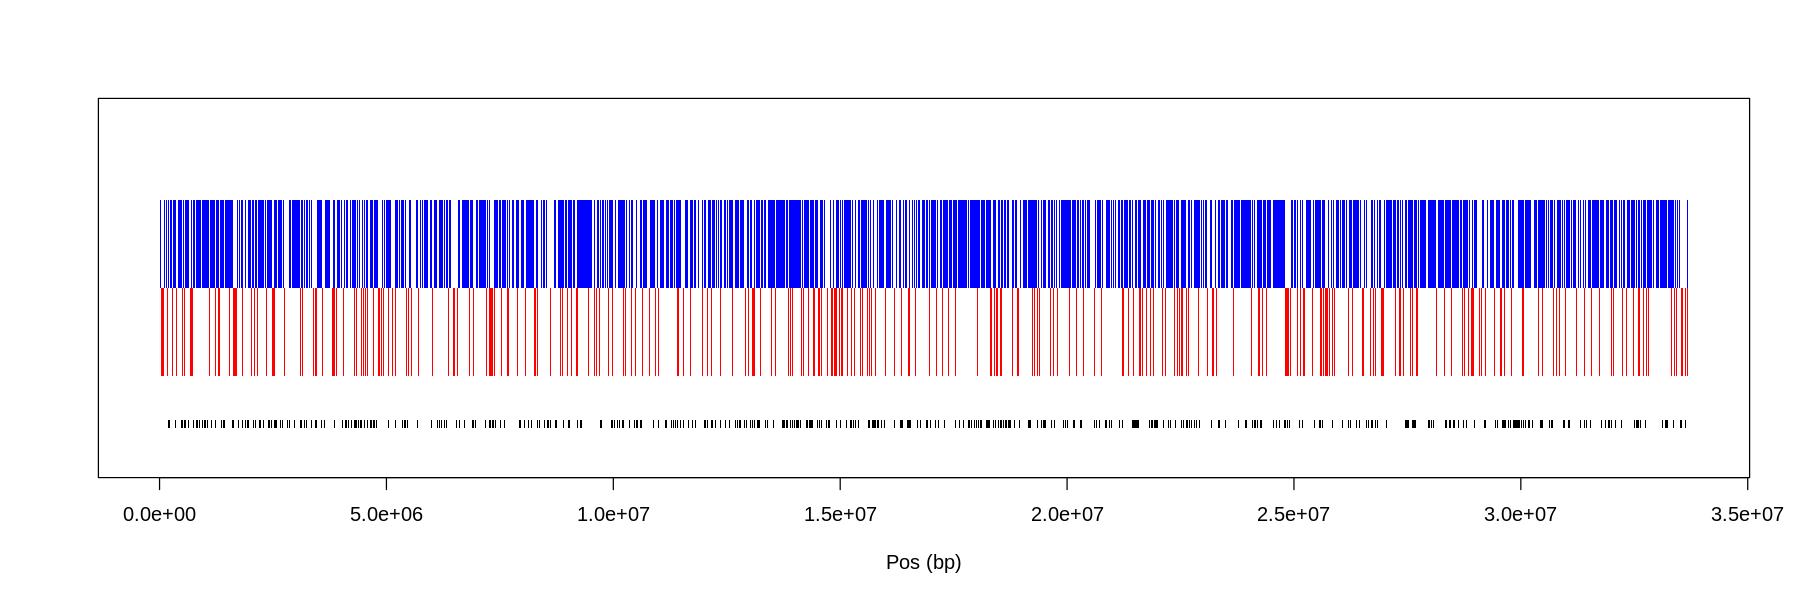

In [259]:
plot(NA,xlim = c(0, max(as.numeric(a[,3]))),ylim =c(0,1),yaxt = "n",xlab = "Pos (bp)",ylab = "")
rect(xleft = as.numeric(a[,2]),xright = as.numeric(a[,3]),
     ybottom = ifelse(a[,4],0.5,0.25),ytop = ifelse(a[,4],0.75,0.5),border = NA,
     col = ifelse(a[,4],"blue","red"))
rect(xleft = gff_Ac_ctg1[,4],xright = gff_Ac_ctg1[,5],
     ybottom = 0.1,ytop = .125,border = NA,
     col = "black")


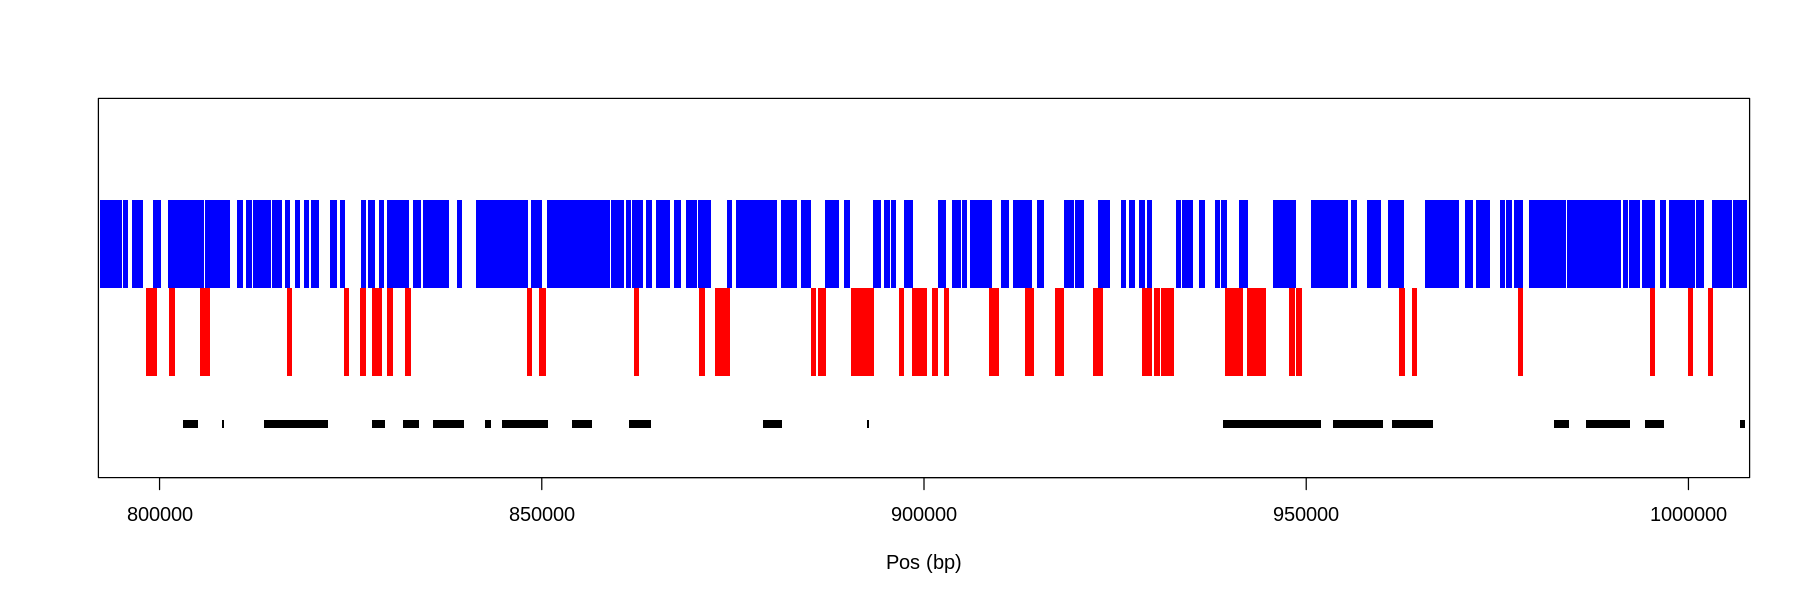

In [262]:
plot(NA,xlim = c(8e5, 1e6),ylim =c(0,1),yaxt = "n",xlab = "Pos (bp)",ylab = "")
rect(xleft = as.numeric(a[,2]),xright = as.numeric(a[,3]),
     ybottom = ifelse(a[,4],0.5,0.25),ytop = ifelse(a[,4],0.75,0.5),border = NA,
     col = ifelse(a[,4],"blue","red"))
rect(xleft = gff_Ac_ctg1[,4],xright = gff_Ac_ctg1[,5],
     ybottom = 0.1,ytop = .125,border = NA,
     col = "black")


In [257]:
head(gff_Ac_ctg1)

DataFrame with 6 rows and 16 columns
     seqid   source     type     start       end     score      strand
  <factor> <factor> <factor> <integer> <integer> <numeric> <character>
1    ctg_1   PanAnd     gene    165372    170719        NA           +
2    ctg_1   PanAnd     gene    195610    199299        NA           +
3    ctg_1   PanAnd     gene    204932    222955        NA           -
4    ctg_1   PanAnd     gene    333288    337363        NA           +
5    ctg_1   PanAnd     gene    338954    343283        NA           +
6    ctg_1   PanAnd     gene    347230    349663        NA           +
      phase              ID        biotype  logic_name          Parent
  <integer>     <character>    <character> <character> <CharacterList>
1        NA Ac00001aa000001 protein_coding   BIND_gene                
2        NA Ac00001aa000002 protein_coding   BIND_gene                
3        NA Ac00001aa000003 protein_coding   BIND_gene                
4        NA Ac00001aa000004 protein_codi